#   Video Segmentation with MedSAM2
This notebook shows how to use MedSAM2 for video segmentation inference. 

If running locally using jupyter, first install `MedSAM2` in your environment using the [installation instructions](https://github.com/bowang-lab/MedSAM2?tab=readme-ov-file#installation) in the repository.

## Load Packages and MedsSAM2 video predictor

In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sam2.build_sam import build_sam2_video_predictor

# helper functions
DAVIS_PALETTE = b"\x00\x00\x00\x80\x00\x00\x00\x80\x00\x80\x80\x00\x00\x00\x80\x80\x00\x80\x00\x80\x80\x80\x80\x80@\x00\x00\xc0\x00\x00@\x80\x00\xc0\x80\x00@\x00\x80\xc0\x00\x80@\x80\x80\xc0\x80\x80\x00@\x00\x80@\x00\x00\xc0\x00\x80\xc0\x00\x00@\x80\x80@\x80\x00\xc0\x80\x80\xc0\x80@@\x00\xc0@\x00@\xc0\x00\xc0\xc0\x00@@\x80\xc0@\x80@\xc0\x80\xc0\xc0\x80\x00\x00@\x80\x00@\x00\x80@\x80\x80@\x00\x00\xc0\x80\x00\xc0\x00\x80\xc0\x80\x80\xc0@\x00@\xc0\x00@@\x80@\xc0\x80@@\x00\xc0\xc0\x00\xc0@\x80\xc0\xc0\x80\xc0\x00@@\x80@@\x00\xc0@\x80\xc0@\x00@\xc0\x80@\xc0\x00\xc0\xc0\x80\xc0\xc0@@@\xc0@@@\xc0@\xc0\xc0@@@\xc0\xc0@\xc0@\xc0\xc0\xc0\xc0\xc0 \x00\x00\xa0\x00\x00 \x80\x00\xa0\x80\x00 \x00\x80\xa0\x00\x80 \x80\x80\xa0\x80\x80`\x00\x00\xe0\x00\x00`\x80\x00\xe0\x80\x00`\x00\x80\xe0\x00\x80`\x80\x80\xe0\x80\x80 @\x00\xa0@\x00 \xc0\x00\xa0\xc0\x00 @\x80\xa0@\x80 \xc0\x80\xa0\xc0\x80`@\x00\xe0@\x00`\xc0\x00\xe0\xc0\x00`@\x80\xe0@\x80`\xc0\x80\xe0\xc0\x80 \x00@\xa0\x00@ \x80@\xa0\x80@ \x00\xc0\xa0\x00\xc0 \x80\xc0\xa0\x80\xc0`\x00@\xe0\x00@`\x80@\xe0\x80@`\x00\xc0\xe0\x00\xc0`\x80\xc0\xe0\x80\xc0 @@\xa0@@ \xc0@\xa0\xc0@ @\xc0\xa0@\xc0 \xc0\xc0\xa0\xc0\xc0`@@\xe0@@`\xc0@\xe0\xc0@`@\xc0\xe0@\xc0`\xc0\xc0\xe0\xc0\xc0\x00 \x00\x80 \x00\x00\xa0\x00\x80\xa0\x00\x00 \x80\x80 \x80\x00\xa0\x80\x80\xa0\x80@ \x00\xc0 \x00@\xa0\x00\xc0\xa0\x00@ \x80\xc0 \x80@\xa0\x80\xc0\xa0\x80\x00`\x00\x80`\x00\x00\xe0\x00\x80\xe0\x00\x00`\x80\x80`\x80\x00\xe0\x80\x80\xe0\x80@`\x00\xc0`\x00@\xe0\x00\xc0\xe0\x00@`\x80\xc0`\x80@\xe0\x80\xc0\xe0\x80\x00 @\x80 @\x00\xa0@\x80\xa0@\x00 \xc0\x80 \xc0\x00\xa0\xc0\x80\xa0\xc0@ @\xc0 @@\xa0@\xc0\xa0@@ \xc0\xc0 \xc0@\xa0\xc0\xc0\xa0\xc0\x00`@\x80`@\x00\xe0@\x80\xe0@\x00`\xc0\x80`\xc0\x00\xe0\xc0\x80\xe0\xc0@`@\xc0`@@\xe0@\xc0\xe0@@`\xc0\xc0`\xc0@\xe0\xc0\xc0\xe0\xc0  \x00\xa0 \x00 \xa0\x00\xa0\xa0\x00  \x80\xa0 \x80 \xa0\x80\xa0\xa0\x80` \x00\xe0 \x00`\xa0\x00\xe0\xa0\x00` \x80\xe0 \x80`\xa0\x80\xe0\xa0\x80 `\x00\xa0`\x00 \xe0\x00\xa0\xe0\x00 `\x80\xa0`\x80 \xe0\x80\xa0\xe0\x80``\x00\xe0`\x00`\xe0\x00\xe0\xe0\x00``\x80\xe0`\x80`\xe0\x80\xe0\xe0\x80  @\xa0 @ \xa0@\xa0\xa0@  \xc0\xa0 \xc0 \xa0\xc0\xa0\xa0\xc0` @\xe0 @`\xa0@\xe0\xa0@` \xc0\xe0 \xc0`\xa0\xc0\xe0\xa0\xc0 `@\xa0`@ \xe0@\xa0\xe0@ `\xc0\xa0`\xc0 \xe0\xc0\xa0\xe0\xc0``@\xe0`@`\xe0@\xe0\xe0@``\xc0\xe0`\xc0`\xe0\xc0\xe0\xe0\xc0"

def load_ann_png(path):
    """Load a PNG file as a mask and its palette."""
    mask = Image.open(path)
    palette = mask.getpalette()
    mask = np.array(mask).astype(np.uint8)
    print ("load_ann_png: ",mask.shape)
    return mask, palette

def get_per_obj_mask(mask):
    """Split a mask into per-object masks."""
    if mask.ndim == 3:
    # RGB mask → binary mask
        mask = np.any(mask != 0, axis=-1)
    elif mask.ndim == 2:
        # Already 2D, just ensure it's boolean
        mask = mask != 0
    else:
        raise ValueError(f"Unexpected mask shape: {mask.shape}")    
    object_ids = np.unique(mask)
    object_ids = object_ids[object_ids > 0].tolist()
    per_obj_mask = {object_id: (mask == object_id) for object_id in object_ids}
    return per_obj_mask

def put_per_obj_mask(per_obj_mask, height, width):
    """Combine per-object masks into a single mask."""
    mask = np.zeros((height, width), dtype=np.uint8)
    object_ids = sorted(per_obj_mask)[::-1]
    for object_id in object_ids:
        object_mask = per_obj_mask[object_id]
        object_mask = object_mask.reshape(height, width)
        mask[object_mask] = object_id
    return mask

def load_masks_from_dir(input_mask_path):
    input_mask, input_palette = load_ann_png(input_mask_path)
    per_obj_input_mask = get_per_obj_mask(input_mask)
    return per_obj_input_mask, input_palette

def save_predictions_to_dir(
    output_mask_dir,
    video_name,
    frame_name,
    per_obj_output_mask,
    height,
    width,
):
    """Save masks to a directory as PNG files."""
    os.makedirs(os.path.join(output_mask_dir, video_name), exist_ok=True)

    output_mask = put_per_obj_mask(per_obj_output_mask, height, width)
    output_mask_path = os.path.join(
        output_mask_dir, video_name, f"{frame_name}.png"
    )
    assert output_mask.dtype == np.uint8
    assert output_mask.ndim == 2
    output_mask = Image.fromarray(output_mask)
    output_mask.save(output_mask_path)

def create_overlay(img_path, mask_path, palette):
    """Create an overlay of an image and a mask."""
    img = Image.open(img_path)
    mask = Image.open(mask_path)
    mask.putpalette(palette)
    mask_rgb = mask.convert("RGB")
    mask_rgb = mask_rgb.resize(img.size, Image.NEAREST)
    overlay = Image.blend(img, mask_rgb, alpha=0.5)
    return overlay

def show_mask(mask, ax, obj_id=None, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        cmap = plt.get_cmap("tab10")
        cmap_idx = 0 if obj_id is None else obj_id
        color = np.array([*cmap(cmap_idx)[:3], 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)
    

In [22]:
pwd

'/home/lokesha/Documents/Codes/MedSAM2_Jun_Ma/MedSAM2/notebooks'

In [23]:
# change to customized path
VIDEO_DIR = "/home/lokesha/Documents/Codes/MedSAM2_Jun_Ma/MedSAM2/media/Indexed/images"
VIDEO_NAME = "D_NBI_129_20190115_0_8"
INITIAL_MASK_PROMPT = "/home/lokesha/Documents/Codes/MedSAM2_Jun_Ma/MedSAM2/media/Indexed/masks/D_NBI_129_20190115_0_8/0.jpg"
OUTPUT_DIR = "/home/lokesha/Documents/Codes/MedSAM2_Jun_Ma/MedSAM2/media/predictions/D_NBI_129_20190115_0_8"
GROUND_TRUTH_MASK_DIR = "/home/lokesha/Documents/Codes/MedSAM2_Jun_Ma/MedSAM2/media/Indexed/masks/"

MODEL_CONFIG = "configs/sam2.1_hiera_t512.yaml"
MODEL_CHECKPOINT = "/home/lokesha/Documents/Codes/MedSAM2_Jun_Ma/MedSAM2/checkpoints/MedSAM2_latest.pt"

predictor = build_sam2_video_predictor(
    config_file=MODEL_CONFIG,
    ckpt_path=MODEL_CHECKPOINT,
    apply_postprocessing=True,
    # hydra_overrides_extra=hydra_overrides_extra,
    vos_optimized=  True,
)

## Prepare Inference and Add Initial Mask Prompt

frame loading (JPEG): 100%|██████████| 305/305 [00:05<00:00, 56.70it/s]


load_ann_png:  (1072, 1230)
dict_keys([True])
1
object_mask.dim()  (1072, 1230)
out_mask_logits.shape:  torch.Size([1, 1072, 1230])


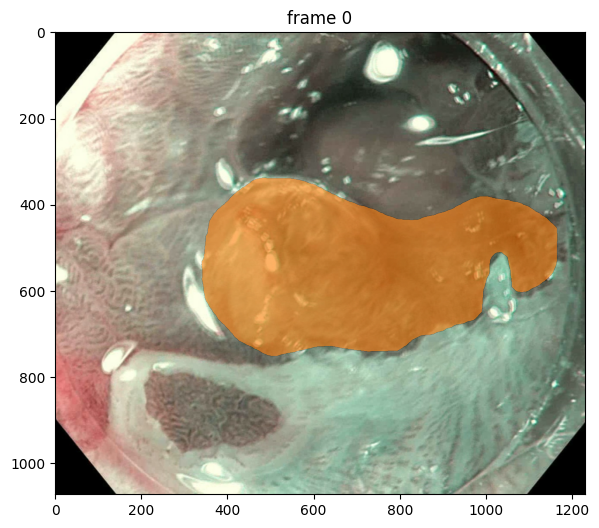

In [24]:
# load the video frames
frame_names = [
        os.path.splitext(p)[0]
        for p in os.listdir(os.path.join(VIDEO_DIR, VIDEO_NAME))
        if os.path.splitext(p)[-1] in [".jpg", ".jpeg", ".JPG", ".JPEG"]
    ]
frame_names = list(sorted(frame_names))
inference_state = predictor.init_state(
    video_path=os.path.join(VIDEO_DIR, VIDEO_NAME), async_loading_frames=False
)
height = inference_state["video_height"]
width = inference_state["video_width"]
input_palette = None

# Add input masks to MedSAM2 inference state before propagation
object_ids_set = None
input_frame_idx = 0  # use first frame as mask input
try:
    per_obj_input_mask, input_palette = load_masks_from_dir(input_mask_path=INITIAL_MASK_PROMPT)
    #print ("per_obj_input_mask: ",per_obj_input_mask.shape)
except FileNotFoundError as e:
    raise RuntimeError(
        f"In {VIDEO_NAME=}, failed to load input mask for frame {input_frame_idx=}. "
        "Please add the `--track_object_appearing_later_in_video` flag "
        "for VOS datasets that don't have all objects to track appearing "
        "in the first frame (such as LVOS or YouTube-VOS)."
    ) from e

# get the list of object ids to track from the first input frame
if object_ids_set is None:
    object_ids_set = set(per_obj_input_mask)
print(per_obj_input_mask.keys())  # shows all object IDs
print(len(per_obj_input_mask))    # number of objects
for object_id, object_mask in per_obj_input_mask.items():
    # check and make sure no new object ids appear only in later frames
    if object_id not in object_ids_set:
        raise RuntimeError(
            f"In {VIDEO_NAME=}, got a new {object_id=} appearing only in a "
            f"later {input_frame_idx=} (but not appearing in the first frame). "
            "Please add the `--track_object_appearing_later_in_video` flag "
            "for VOS datasets that don't have all objects to track appearing "
            "in the first frame (such as LVOS or YouTube-VOS)."
        )
    # object_mask = np.any(object_mask != 0, axis=-1) 
    print ("object_mask.dim() ",object_mask.shape)

    _, out_obj_ids, out_mask_logits = predictor.add_new_mask(
        inference_state=inference_state,
        frame_idx=input_frame_idx,
        obj_id=object_id,
        mask=object_mask,
            )

# show the results on the current (interacted) frame
plt.figure(figsize=(9, 6))
plt.title(f"frame {input_frame_idx}")
plt.imshow(Image.open(os.path.join(VIDEO_DIR, VIDEO_NAME, f"{frame_names[input_frame_idx]}.jpg")))
show_mask((out_mask_logits[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_ids[0])
print ("out_mask_logits.shape: ",out_mask_logits[0].shape)
    
# check and make sure we have at least one object to track
if object_ids_set is None or len(object_ids_set) == 0:
    raise RuntimeError(
        f"In {VIDEO_NAME=}, got no object ids on {input_frame_idx=}. "
        "Please add the `--track_object_appearing_later_in_video` flag "
        "for VOS datasets that don't have all objects to track appearing "
        "in the first frame (such as LVOS or YouTube-VOS)."
    )

## Run Inference

In [25]:
# run propagation throughout the video
os.makedirs(os.path.join(OUTPUT_DIR, VIDEO_NAME), exist_ok=True)

video_segments = {}  # Store the per-frame segmentation results
for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
    per_obj_output_mask = {
        out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(out_obj_ids)
    }
    video_segments[out_frame_idx] = per_obj_output_mask


vis_frame_stride = 1
plt.close("all")
# for out_frame_idx in range(0, len(frame_names), vis_frame_stride):
#     plt.figure(figsize=(6, 4))
#     plt.title(f"frame {out_frame_idx}")
#     plt.imshow(Image.open(os.path.join(VIDEO_DIR, VIDEO_NAME,  f"{frame_names[out_frame_idx]}.jpg")))
#     for out_obj_id, out_mask in video_segments[out_frame_idx].items():
#         show_mask(out_mask, plt.gca(), obj_id=out_obj_id)
#         print (out_mask.shape)


for out_frame_idx in range(0, len(frame_names), vis_frame_stride):

    
    frame_name = frame_names[out_frame_idx]
    print(frame_name)
    print(out_frame_idx)
    # Load RGB frame
    img = Image.open(os.path.join(VIDEO_DIR, VIDEO_NAME, f"{frame_name}.jpg"))

    # Load ground truth mask image (you can convert it to grayscale if needed)
    gt_mask_path = os.path.join(GROUND_TRUTH_MASK_DIR, VIDEO_NAME,f"{frame_name}.jpg")
    gt_mask = Image.open(gt_mask_path).convert("L")  # grayscale mask

    # fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    # fig.suptitle(f"Frame {out_frame_idx}", fontsize=14)

    # # Left: input image with predicted masks
    # axes[0].imshow(img)
    # axes[0].set_title("Predicted")
    # axes[0].axis("off")

    # for out_obj_id, out_mask in video_segments[out_frame_idx].items():
    #     show_mask(out_mask, axes[0], obj_id=out_obj_id)
       

    # # Right: ground truth
    # axes[1].imshow(gt_mask, cmap="gray")
    # axes[1].set_title("Ground Truth")
    # axes[1].axis("off")

   
    #plt.show()

    fig, ax = plt.subplots(figsize=(8, 6))
    #fig.suptitle(f"Frame {out_frame_idx}", fontsize=14)

    # Show the input image
    ax.imshow(img)
    ax.set_title("Predicted + Ground Truth")
    ax.axis("off")
    
    

    # Convert ground truth to NumPy and normalize to [0,1]
    gt_mask_np = np.array(gt_mask) / 255.0

    # Create transparent green overlay
    green_overlay = np.zeros((gt_mask_np.shape[0], gt_mask_np.shape[1], 4))
    green_overlay[..., 1] = 1.0  # green channel
    green_overlay[..., 3] = gt_mask_np * 0.4  # alpha based on mask

    # Overlay ground truth
    ax.imshow(green_overlay)

    # Show predicted masks
    for out_obj_id, out_mask in video_segments[out_frame_idx].items():
        show_mask(out_mask, ax, obj_id=out_obj_id)

    save_path = os.path.join(OUTPUT_DIR, VIDEO_NAME, f"{frame_name}_vis.png")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    
    plt.close(fig) 

# write the output masks
# for out_frame_idx, per_obj_output_mask in video_segments.items():
#     print(f"Obj ID: {out_obj_id}, Non-zero mask pixels: {np.sum(out_mask)}")
#     # save raw prediction results
#     save_predictions_to_dir(
#         output_mask_dir=OUTPUT_DIR,
#         video_name=VIDEO_NAME,
#         frame_name=frame_names[out_frame_idx],
#         per_obj_output_mask=per_obj_output_mask,
#         height=height,
#         width=width,
#     )

propagate in video: 100%|██████████| 305/305 [00:07<00:00, 40.63it/s]


0
0
1
1
10
2
100
3
101
4
102
5
103
6
104
7
105
8
106
9
107
10
108
11
109
12
11
13
110
14
111
15
112
16
113
17
114
18
115
19
116
20
117
21
118
22
119
23
12
24
120
25
121
26
122
27
123
28
124
29
125
30
126
31
127
32
128
33
129
34
13
35
130
36
131
37
132
38
133
39
134
40
135
41
136
42
137
43
138
44
139
45
14
46
140
47
141
48
142
49
143
50
144
51
145
52
146
53
147
54
148
55
149
56
15
57
150
58
151
59
152
60
153
61
154
62
155
63
156
64
157
65
158
66
159
67
16
68
160
69
161
70
162
71
163
72
164
73
165
74
166
75
167
76
168
77
169
78
17
79
170
80
171
81
172
82
173
83
174
84
175
85
176
86
177
87
178
88
179
89
18
90
180
91
181
92
182
93
183
94
184
95
185
96
186
97
187
98
188
99
189
100
19
101
190
102
191
103
192
104
193
105
194
106
195
107
196
108
197
109
198
110
199
111
2
112
20
113
200
114
201
115
202
116
203
117
204
118
205
119
206
120
207
121
208
122
209
123
21
124
210
125
211
126
212
127
213
128
214
129
215
130
216
131
217
132
218
133
219
134
22
135
220
136
221
137
222
138
223
139
224
140
2

In [ ]:
#Multiple prompts

['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '5', '6', '7', '8', '9']
input_frame_idx:  22
dict_keys([True])
1
torch.Size([1, 1, 1080, 1380])


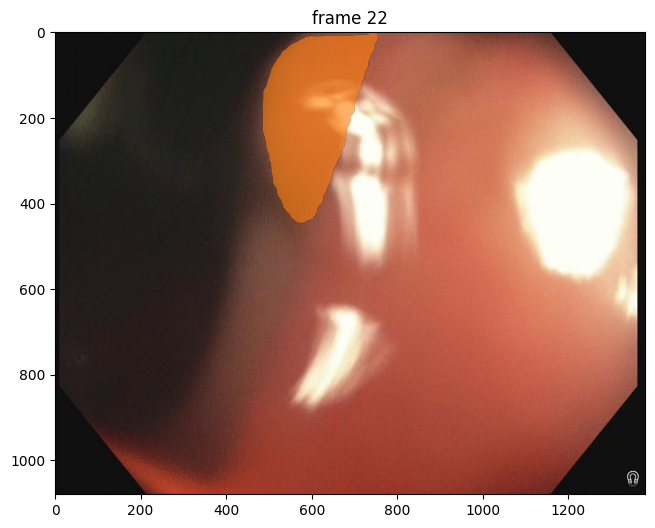

In [ ]:
# Add input masks to MedSAM2 inference state before propagation
prompt_frames = [22]
PROMPT_SOURCE = "/home/lokesha/Documents/Codes/MedSAM2_Jun_Ma/MedSAM2/media/mask/"
print (frame_names)
for n in prompt_frames:
    object_ids_set = None
    input_frame_idx = n  # use first frame as mask input
    print("input_frame_idx: ", input_frame_idx)
    try:
        per_obj_input_mask, input_palette = load_masks_from_dir(input_mask_path=os.path.join(PROMPT_SOURCE,VIDEO_NAME,
                                                                                             f"{input_frame_idx}.jpg"  ))
    except FileNotFoundError as e:
        raise RuntimeError(
            f"In {VIDEO_NAME=}, failed to load input mask for frame {input_frame_idx=}. "
            "Please add the `--track_object_appearing_later_in_video` flag "
            "for VOS datasets that don't have all objects to track appearing "
            "in the first frame (such as LVOS or YouTube-VOS)."
        ) from e
    
    # get the list of object ids to track from the first input frame
    if object_ids_set is None:
        object_ids_set = set(per_obj_input_mask)
    print(per_obj_input_mask.keys())  # shows all object IDs
    print(len(per_obj_input_mask))    # number of objects
    for object_id, object_mask in per_obj_input_mask.items():
        # check and make sure no new object ids appear only in later frames
        if object_id not in object_ids_set:
            raise RuntimeError(
                f"In {VIDEO_NAME=}, got a new {object_id=} appearing only in a "
                f"later {input_frame_idx=} (but not appearing in the first frame). "
                "Please add the `--track_object_appearing_later_in_video` flag "
                "for VOS datasets that don't have all objects to track appearing "
                "in the first frame (such as LVOS or YouTube-VOS)."
            )
        # object_mask = np.any(object_mask != 0, axis=-1) 
        _, out_obj_ids, out_mask_logits = predictor.add_new_mask(
            inference_state=inference_state,
            frame_idx=input_frame_idx,
            obj_id=object_id,
            mask=object_mask,
                )
    
    # show the results on the current (interacted) frame
    plt.figure(figsize=(9, 6))
    plt.title(f"frame {input_frame_idx}")
    plt.imshow(Image.open(os.path.join(VIDEO_DIR, VIDEO_NAME, f"{input_frame_idx}.jpg")))
    show_mask((out_mask_logits[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_ids[0])
    print (out_mask_logits.shape)
        
    # check and make sure we have at least one object to track
    if object_ids_set is None or len(object_ids_set) == 0:
        raise RuntimeError(
            f"In {VIDEO_NAME=}, got no object ids on {input_frame_idx=}. "
            "Please add the `--track_object_appearing_later_in_video` flag "
            "for VOS datasets that don't have all objects to track appearing "
            "in the first frame (such as LVOS or YouTube-VOS).")
